# Step_1 `Audio Acquisition & Analysis :`

Cell 1 — `Install & Imports`

In [1]:
# Imports
import sounddevice as sd
from scipy.io.wavfile import write
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import noisereduce as nr

c:\Users\LoQ\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cell 2 — `Audio Recording Settings`

In [2]:
# إعدادات التسجيل

sample_rate = 16000   # عدد العينات في الثانية
duration = 3          # مدة التسجيل بالثواني
channels = 1          # Mono Audio

output_file = "recorded_audio.wav"

Cell 3 — `Record Audio`

In [3]:
print("Recording Started...")

audio = sd.rec(
    int(duration * sample_rate),
    samplerate=sample_rate,
    channels=channels,
    dtype='float32'
)

sd.wait()

print("Recording Finished!")

# حفظ الملف
audio = audio.flatten()
write(output_file, sample_rate, audio)

Recording Started...
Recording Finished!


Cell 4 — `Load Audio`

In [4]:
# تحميل الصوت للتحليل

signal, sr = librosa.load(output_file, sr=sample_rate)

print("Signal Shape:", signal.shape)
print("Sample Rate:", sr)

Signal Shape: (48000,)
Sample Rate: 16000


Cell 5 — `Plot Waveform`

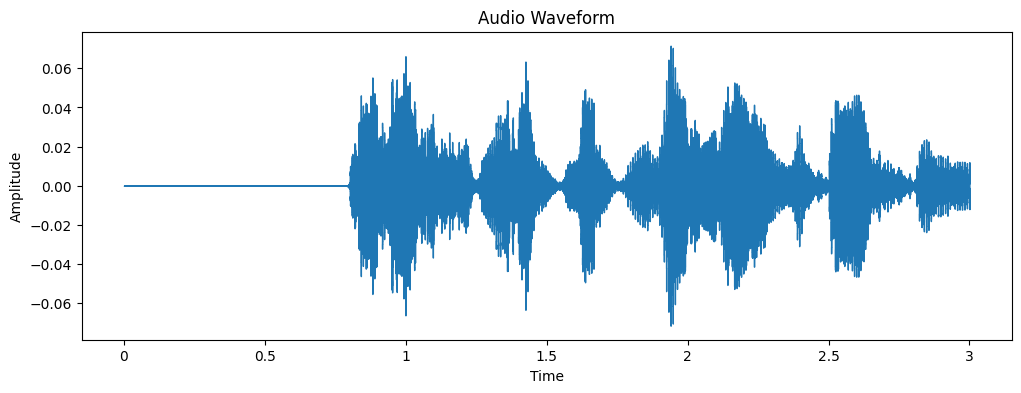

In [5]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(signal, sr=sr)

plt.title("Audio Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

Cell 6 — `FFT (Frequency Analysis)`

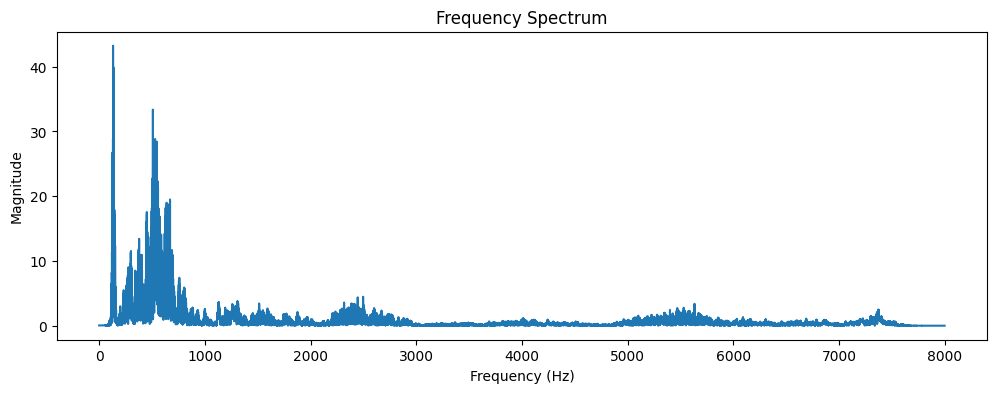

In [6]:
# تطبيق Fast Fourier Transform

fft = np.fft.fft(signal)

magnitude = np.abs(fft)

frequency = np.linspace(0, sr, len(magnitude))

plt.figure(figsize=(12,4))

plt.plot(frequency[:len(frequency)//2],
         magnitude[:len(magnitude)//2])

plt.title("Frequency Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.show()

Cell 7 — `Zero Crossing Rate`

In [7]:
zcr = librosa.feature.zero_crossing_rate(signal)

print("Zero Crossing Rate:")
print(np.mean(zcr))

Zero Crossing Rate:
0.16969851230053193


Cell 8 — `RMS Energy`

In [8]:
rms = librosa.feature.rms(y=signal)

print("RMS Energy:")
print(np.mean(rms))

RMS Energy:
0.008428704


Cell 9 — `Signal Power`

In [9]:
signal_power = np.mean(signal**2)

print("Signal Power:")
print(signal_power)

Signal Power:
0.00011501723


# Step_2 `DSP & Noise Reduction :`

Cell 1 — `Imports`

In [10]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

Cell 2 — `Load Audio`

In [11]:
audio_path = "recorded_audio.wav"

signal, sr = librosa.load(audio_path, sr=16000)

print("Audio Loaded")
print("Sample Rate:", sr)
print("Signal Length:", len(signal))

Audio Loaded
Sample Rate: 16000
Signal Length: 48000


Cell 3 — `Signal Normalization`

In [12]:
normalized_signal = signal / np.max(np.abs(signal))

print("Normalization Done")

Normalization Done


Cell 4 — `Plot Before & After Normalization`

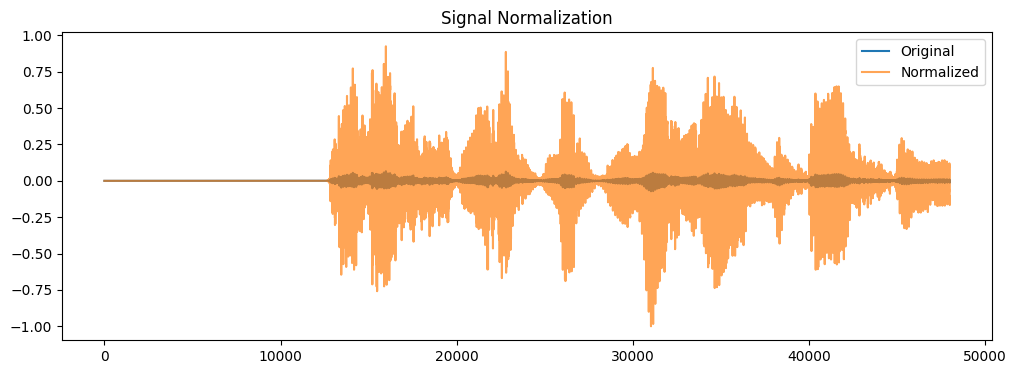

In [13]:
plt.figure(figsize=(12,4))

plt.plot(signal, label="Original")
plt.plot(normalized_signal, label="Normalized", alpha=0.7)

plt.title("Signal Normalization")
plt.legend()

plt.show()

Cell 5 — `Pre-emphasis Filter`

In [14]:
pre_emphasis = 0.97

emphasized_signal = np.append(
    normalized_signal[0],
    normalized_signal[1:] - pre_emphasis * normalized_signal[:-1]
)

print("Pre-emphasis Applied")

Pre-emphasis Applied


Cell 6 — `Voice Activity Detection (VAD)`

In [15]:
intervals = librosa.effects.split(
    emphasized_signal,
    top_db=35 ,
    hop_length=512
)

speech_signal = np.concatenate(
    [emphasized_signal[start:end] for start, end in intervals]
)

print("Silence Removed")

Silence Removed


Cell 7 — `Noise reduce`

In [16]:
reduced_noise = nr.reduce_noise(
    y=speech_signal,
    sr=sr
)

In [17]:
sf.write("cleaned_voice.wav", speech_signal, sr)
print("Cleaned audio saved as 'cleaned_voice.wav'")

Cleaned audio saved as 'cleaned_voice.wav'


Cell 8 — `Framing`

In [18]:
frame_size = 0.025
frame_stride = 0.01

frame_length = int(frame_size * sr)
frame_step = int(frame_stride * sr)

signal_length = len(speech_signal)

num_frames = int(
    np.ceil(
        float(np.abs(signal_length - frame_length))
        / frame_step
    )
)

pad_signal_length = num_frames * frame_step + frame_length

z = np.zeros((pad_signal_length - signal_length))

pad_signal = np.append(speech_signal, z)

indices = (
    np.tile(np.arange(0, frame_length), (num_frames, 1))
    + np.tile(
        np.arange(0, num_frames * frame_step, frame_step),
        (frame_length, 1)
    ).T
)

frames = pad_signal[indices.astype(np.int32, copy=False)]

print("Framing Done")
print("Number of Frames:", len(frames))

Framing Done
Number of Frames: 221


Cell 9 — `Noise Estimation`

In [19]:
noise_profile = np.mean(np.abs(frames), axis=0)

print("Noise Profile Estimated")

Noise Profile Estimated


Cell 10 — `Hamming Window`

In [20]:
frames *= np.hamming(frame_length)

print("Hamming Window Applied")

Hamming Window Applied


Cell 11 — `Spectrogram`

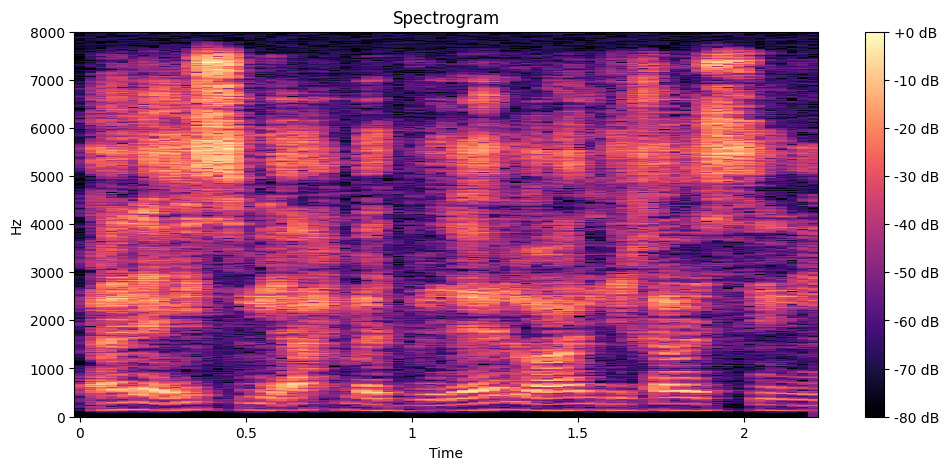

In [21]:
plt.figure(figsize=(12,5))

D = librosa.amplitude_to_db(
    np.abs(librosa.stft(speech_signal)),
    ref=np.max
)

librosa.display.specshow(
    D,
    sr=sr,
    x_axis='time',
    y_axis='hz'
)

plt.colorbar(format='%+2.0f dB')

plt.title("Spectrogram")

plt.show()

# Step_3 `Acoustic Feature Extraction`

Cell 1 — `Imports`

In [22]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

Cell 2 — `Load Clean Audi`o

In [23]:
signal = speech_signal 
sr = 16000

print("Feature Extraction starting on the CLEANED signal...")

Feature Extraction starting on the CLEANED signal...


Cell 3 — `MFCC Extraction`

In [24]:
mfccs = librosa.feature.mfcc(
    y=signal,
    sr=sr,
    n_mfcc=13
)

print("MFCC Shape:", mfccs.shape)

MFCC Shape: (13, 70)


Cell 4 — `Visualize MFCC`

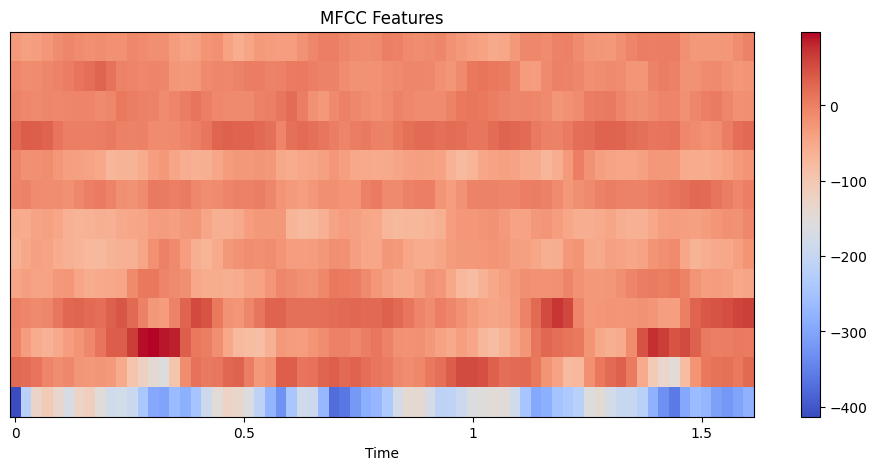

In [25]:
plt.figure(figsize=(12,5))

librosa.display.specshow(
    mfccs,
    x_axis='time'
)

plt.colorbar()

plt.title("MFCC Features")

plt.show()

Cell 5 — `Delta MFCC`

In [26]:
delta_mfcc = librosa.feature.delta(mfccs)

print("Delta MFCC Shape:", delta_mfcc.shape)

Delta MFCC Shape: (13, 70)


Cell 6 — `Delta-Delta MFCC`

In [27]:
delta2_mfcc = librosa.feature.delta(
    mfccs,
    order=2
)

print("Delta-Delta Shape:", delta2_mfcc.shape)

Delta-Delta Shape: (13, 70)


Cell 7 — `Mel Spectrogram`

In [28]:
mel_spec = librosa.feature.melspectrogram(
    y=signal,
    sr=sr,
    n_mels=128
)

mel_spec_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

print("Mel Spectrogram Created")

Mel Spectrogram Created


Cell 8 — `Visualize Mel Spectrogram`

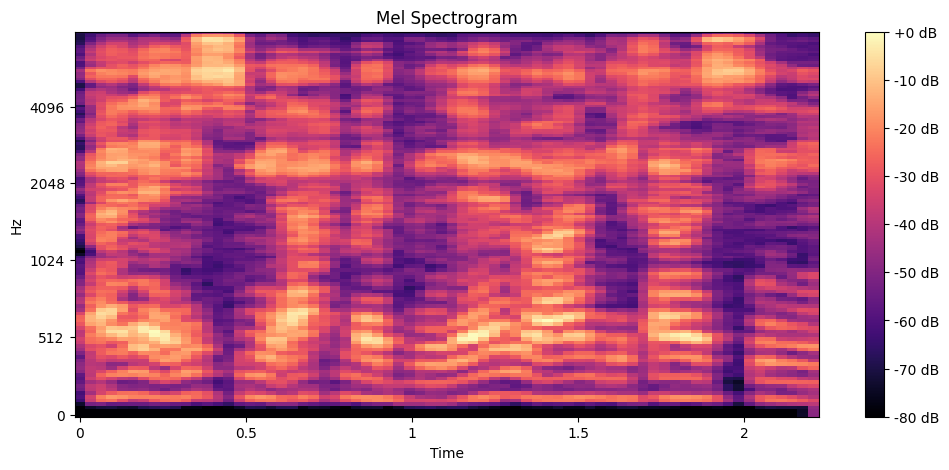

In [29]:
plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')

plt.title("Mel Spectrogram")

plt.show()

Cell 9 — `Pitch Extraction`

In [30]:
pitch, magnitude = librosa.piptrack(
    y=signal,
    sr=sr
)

print("Pitch Extracted")

Pitch Extracted


Cell 10 — `Spectral Centroid`

In [31]:
spectral_centroids = librosa.feature.spectral_centroid(
    y=signal,
    sr=sr
)

print("Spectral Centroid Shape:",
      spectral_centroids.shape)

Spectral Centroid Shape: (1, 70)


Cell 11 — `Spectral Bandwidth`

In [32]:
spectral_bandwidth = librosa.feature.spectral_bandwidth(
    y=signal,
    sr=sr
)

print("Spectral Bandwidth Shape:",
      spectral_bandwidth.shape)

Spectral Bandwidth Shape: (1, 70)


Cell 12 — `Feature Scaling`

In [33]:
scaler = StandardScaler()

mfccs_scaled = scaler.fit_transform(
    mfccs.T
)

print("Feature Scaling Done")

Feature Scaling Done


Cell 13 — `Heatmap Visualization`

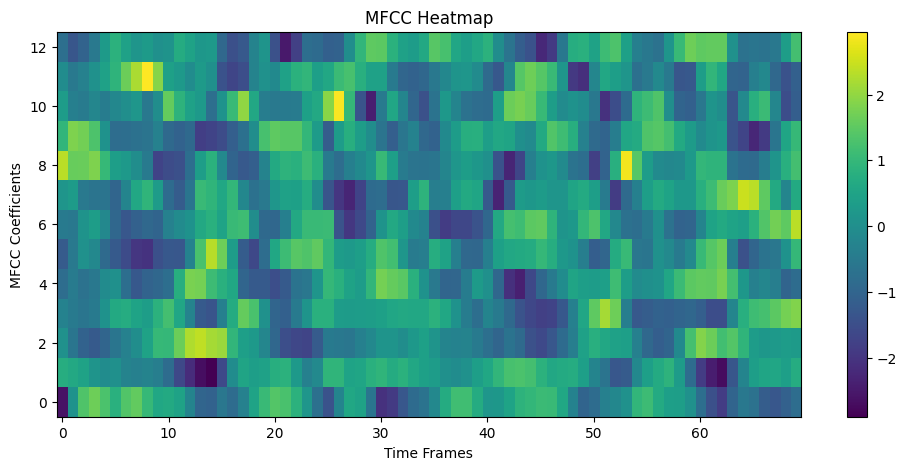

In [34]:
plt.figure(figsize=(12,5))

plt.imshow(
    mfccs_scaled.T,
    aspect='auto',
    origin='lower'
)

plt.colorbar()

plt.title("MFCC Heatmap")

plt.xlabel("Time Frames")
plt.ylabel("MFCC Coefficients")

plt.show()

# Step_4 `AI & Translation:`

Cell 1 — `Imports`

In [35]:
from faster_whisper import WhisperModel
import time
import json
from jiwer import wer

Cell 2 — `Load Model`

In [36]:
model = WhisperModel(
    "small",
    device="cpu",
    compute_type="int8"
)

print("Model Loaded Successfully")


Model Loaded Successfully


Cell 3 — `Transcribe & Translate`

In [37]:
start_time = time.time()

segments, info = model.transcribe(
    speech_signal,
    task="translate",
    language="ar",
    initial_prompt="كلمات مصرية عامية، القاهرة، إزيك، عامل إيه، الجامعة المصرية الروسية", # التلقين
    beam_size=5,
    vad_filter=True
)

segments = list(segments) # خطوة إجبارية عشان الـ Loop يشتغل صح
translated_text = " ".join([segment.text for segment in segments])

end_time = time.time()

print("Detected Language:",
      info.language)



Detected Language: ar


Cell 4 — `Inference Time`

In [38]:
inference_time = end_time - start_time

print("Inference Time:",
      round(inference_time, 2),
      "seconds")

Inference Time: 2.41 seconds


Cell 5 — `Confidence Score`

In [39]:
probs = [np.exp(s.avg_logprob) for s in segments]

if probs:
    average_confidence = (sum(probs) / len(probs)) * 100
else:
    average_confidence = 0

print(f"Confidence: {round(average_confidence, 2)}%")

Confidence: 63.5%


In [40]:
print("\n--- Final English Translation ---")
print(translated_text.strip())


--- Final English Translation ---
My name is Ahmed Bilal and I'm 5 years old


Cell 8 — `JSON Output`

In [41]:
output_data = {

    "translated_text": translated_text.strip(),

    "language": info.language,

    "inference_time_seconds": round(inference_time, 2),

    "confidence_score": round(average_confidence, 2),

    "model_used": "small"
}

with open("translation_output.json", "w") as file:

    json.dump(
        output_data,
        file,
        indent=4
    )

print("JSON File Saved Successfully")

JSON File Saved Successfully
